# eSEED_v2 Loading Conversion

Dataset structure:
- sample_{id}, id = 01 to 48
    - gaze_{i}.csv, i = 1 to 10 (10 recordings per sample)
    - pupil_{i}.csv, i = 1 to 10
    - blinks_{i}.csv, i = 1 to 10
    - annotation_{i}.csv, i = 1 to 10
    - questionnaires.csv
    - subject_info.csv



In [1]:
import os
import yaml
import pandas as pd
import argparse

import numpy as np
import matplotlib.pyplot as plt

In [2]:
data_dir = "/home/ppg/eyetracking/GFM-for-eyetracker/data/raw/eSEEd_v2/split_mat/export_csv"
output_dir = "/home/ppg/eyetracking/GFM-for-eyetracker/data/raw/eSEEd_v2/merged_csv_files"


In [3]:
def merge_eyetracking_data(sample_dir, recording_id):
    """Merge gaze, pupil, blinks, and annotation data for a single recording."""
    
    # Load all data files
    gaze_df = pd.read_csv(os.path.join(sample_dir, f"gaze_{recording_id}.csv"))
    pupil_df = pd.read_csv(os.path.join(sample_dir, f"pupil_{recording_id}.csv"))
    blinks_df = pd.read_csv(os.path.join(sample_dir, f"blinks_{recording_id}.csv"))
    annotation_df = pd.read_csv(os.path.join(sample_dir, f"annotation_{recording_id}.csv"))
    
    # Rename timestamp columns to standard 'timestamp'
    gaze_df = gaze_df.rename(columns={'gaze_timestamp': 'timestamp'})
    pupil_df = pupil_df.rename(columns={'pupil_timestamp': 'timestamp'})
    
    # Merge gaze and pupil on timestamp
    merged_df = pd.merge(gaze_df, pupil_df, on='timestamp', how='outer', suffixes=('_gaze', '_pupil'))
    
    # Sort by timestamp
    merged_df = merged_df.sort_values('timestamp').reset_index(drop=True)
    
    # Initialize blink columns
    merged_df['blink_bool'] = False
    merged_df['blink_confidence'] = None
    merged_df['blink_index'] = None
    
    # Mark blink segments
    for _, blink in blinks_df.iterrows():
        start = blink['start_timestamp']
        end = blink['end_timestamp']
        blink_id = blink['id']
        confidence = blink['confidence']
        
        # Set blink info for all timestamps in blink range
        mask = (merged_df['timestamp'] >= start) & (merged_df['timestamp'] <= end)
        merged_df.loc[mask, 'blink_bool'] = True
        merged_df.loc[mask, 'blink_confidence'] = confidence
        merged_df.loc[mask, 'blink_index'] = blink_id
    
    # Add annotation columns (constant values for entire recording)
    for col in annotation_df.columns:
        merged_df[col] = annotation_df[col].values[0]
    
    # Interpolate missing values in numeric columns (max 5 consecutive gaps)
    for col in merged_df.columns:
        if merged_df[col].dtype in ['float64', 'float32', 'int64', 'int32']:
            merged_df[col] = merged_df[col].interpolate(method='linear', limit=5, limit_direction='both')
    
    return merged_df

In [7]:
def downsample_to_100hz(df):
    """Downsample data to 100Hz using timestamp-based resampling."""
    # Calculate time differences to estimate sampling rate
    df = df.copy().sort_values('timestamp').reset_index(drop=True)
    df['time_seconds'] = df['timestamp'] - df['timestamp'].iloc[0]
    
    # Create uniform 100Hz time grid (0.01 second intervals)
    max_time = df['time_seconds'].max()
    uniform_time = np.arange(0, max_time, 0.01)  # 100Hz = 0.01s intervals
    
    # Create new dataframe with uniform timestamps
    downsampled_df = pd.DataFrame({'time_seconds': uniform_time})
    downsampled_df['timestamp'] = downsampled_df['time_seconds'] + df['timestamp'].iloc[0]
    
    # Interpolate all numeric columns to the new time grid
    for col in df.columns:
        if col not in ['time_seconds', 'timestamp'] and df[col].dtype in ['float64', 'float32', 'int64', 'int32']:
            downsampled_df[col] = np.interp(uniform_time, df['time_seconds'], df[col])
        elif col not in ['time_seconds', 'timestamp']:
            # For non-numeric columns, use nearest neighbor
            df_sorted = df[['timestamp', col]].sort_values('timestamp')
            downsampled_df[col] = pd.merge_asof(
                downsampled_df[['timestamp']], 
                df_sorted, 
                on='timestamp', 
                direction='nearest'
            )[col]
    
    downsampled_df = downsampled_df.drop(columns=['time_seconds'])
    return downsampled_df

def process_sample(sample_id, data_dir, output_dir):
    """Process all recordings for a given sample and merge them."""
    
    sample_dir = os.path.join(data_dir, f"sample_{sample_id:02d}")
    
    all_recordings = []
    
    # Process each recording (1-10)
    for recording_id in range(1, 11):
        try:
            merged_data = merge_eyetracking_data(sample_dir, recording_id)
            merged_data['recording_id'] = recording_id
            all_recordings.append(merged_data)
            print(f"Processed sample_{sample_id:02d}, recording {recording_id}")
        except FileNotFoundError as e:
            print(f"Warning: Missing file for sample_{sample_id:02d}, recording {recording_id}: {e}")
            continue
    
    # Concatenate all recordings for this sample
    if all_recordings:
        sample_df_original = pd.concat(all_recordings, ignore_index=True)
        
        # Downsample to 100Hz
        sample_df = downsample_to_100hz(sample_df_original)
        
        # Save merged data
        os.makedirs(output_dir, exist_ok=True)
        output_path = os.path.join(output_dir, f"sample_{sample_id:02d}_merged.csv")
        sample_df.to_csv(output_path, index=False)
        print(f"Saved: {output_path}")
        
        return sample_df, sample_df_original
    else:
        print(f"No data processed for sample_{sample_id:02d}")
        return None, None

In [8]:
# Test with sample_01
sample_df_downsampled, sample_df_original = process_sample(1, data_dir, output_dir)

# Display info
print(f"\nOriginal shape: {sample_df_original.shape}")
print(f"Downsampled shape: {sample_df_downsampled.shape}")
print(f"\nColumns: {list(sample_df_downsampled.columns)}")
print(f"\nBlink statistics (downsampled):")
print(f"  Total rows: {len(sample_df_downsampled)}")
print(f"  Rows with blinks: {sample_df_downsampled['blink_bool'].sum()}")
sample_df_downsampled.head(10)

Processed sample_01, recording 1
Processed sample_01, recording 2
Processed sample_01, recording 3
Processed sample_01, recording 2
Processed sample_01, recording 3
Processed sample_01, recording 4
Processed sample_01, recording 4
Processed sample_01, recording 5
Processed sample_01, recording 6
Processed sample_01, recording 7
Processed sample_01, recording 5
Processed sample_01, recording 6
Processed sample_01, recording 7
Processed sample_01, recording 8
Processed sample_01, recording 9
Processed sample_01, recording 8
Processed sample_01, recording 9
Processed sample_01, recording 10
Processed sample_01, recording 10
Saved: /home/ppg/eyetracking/GFM-for-eyetracker/data/raw/eSEEd_v2/merged_csv_files/sample_01_merged.csv

Original shape: (331686, 62)
Downsampled shape: (115089, 62)

Columns: ['timestamp', 'world_index_gaze', 'confidence_gaze', 'norm_pos_x_gaze', 'norm_pos_y_gaze', 'base_data', 'gaze_point_3d_x', 'gaze_point_3d_y', 'gaze_point_3d_z', 'eye_center0_3d_x', 'eye_center0_3

,timestamp,world_index_gaze,confidence_gaze,norm_pos_x_gaze,norm_pos_y_gaze,base_data,gaze_point_3d_x,gaze_point_3d_y,gaze_point_3d_z,eye_center0_3d_x,...,projected_sphere_axis_b,projected_sphere_angle,blink_bool,blink_confidence,blink_index,Anger,Tenderness,Disgust,Sadness,recording_id
0,5630.969776,0.000000,0.998070,0.466179,0.909886,5630.961533-0 5630.978018999999-1,-3.337384,-30.581421,66.689672,19.327535,...,173.828993,90.0,False,None,None,0.0,7.0,0.0,0.0,5.0
1,5630.979776,0.000000,0.998166,0.466806,0.908822,5630.978072999999-0 5630.981392-1,-3.275304,-30.619763,66.961215,19.327535,...,184.033315,90.0,False,None,None,0.0,7.0,0.0,0.0,5.0
2,5630.989776,0.237727,0.997535,0.467824,0.908875,NaN,-3.162114,-30.691328,67.114161,19.327535,...,174.804588,90.0,False,None,None,0.0,7.0,0.0,0.0,5.0
3,5630.999776,1.000000,0.997758,0.468035,0.908756,NaN,-3.147257,-30.781358,67.332794,19.327535,...,174.104083,90.0,False,None,None,0.0,7.0,0.0,0.0,5.0
4,5631.009776,1.000000,0.997583,0.469254,0.907799,NaN,-3.018598,-30.880393,67.723775,19.327535,...,183.210553,90.0,False,None,None,0.0,7.0,0.0,0.0,5.0
5,5631.019776,1.000000,0.997728,0.469494,0.906786,5631.017621999999-0 5631.021651-1,-2.968591,-30.592739,67.271265,19.327535,...,178.813382,90.0,False,None,None,0.0,7.0,0.0,0.0,5.0
6,5631.029776,1.322951,0.997824,0.468843,0.905784,NaN,-3.059617,-30.665725,67.604863,19.327535,...,176.459530,90.0,False,None,None,0.0,7.0,0.0,0.0,5.0
7,5631.039776,2.000000,0.998012,0.469938,0.904648,5631.041708-0 5631.038380999999-1,-2.937474,-30.675564,67.832738,19.327535,...,177.093180,90.0,False,None,None,0.0,7.0,0.0,0.0,5.0
8,5631.049776,2.000000,0.997802,0.470098,0.904817,NaN,-2.907991,-30.578549,67.589254,19.327535,...,177.345652,90.0,False,None,None,0.0,7.0,0.0,0.0,5.0
9,5631.059776,2.000000,0.997930,0.469528,0.904153,NaN,-2.987096,-30.648467,67.858426,19.327535,...,179.064740,90.0,False,None,None,0.0,7.0,0.0,0.0,5.0


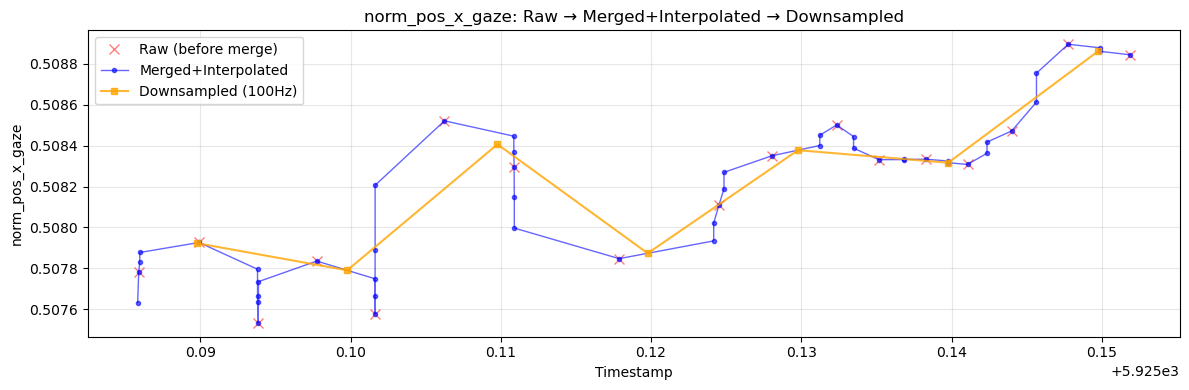

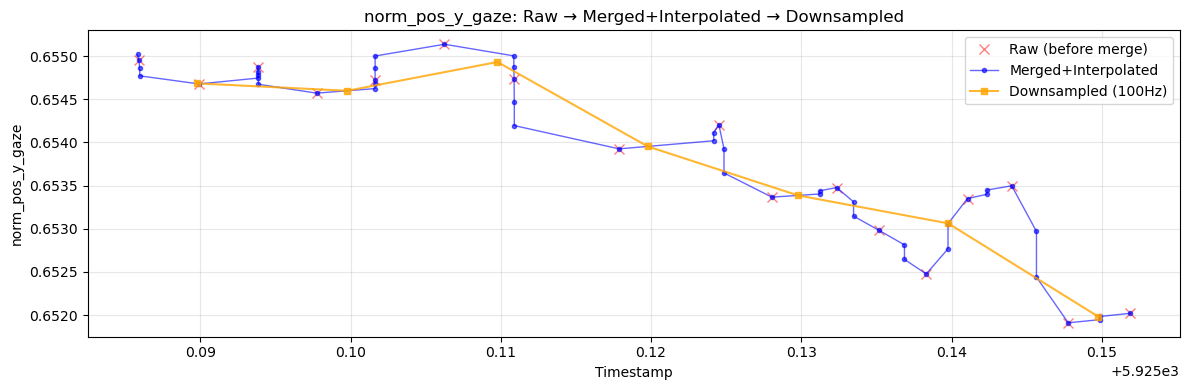

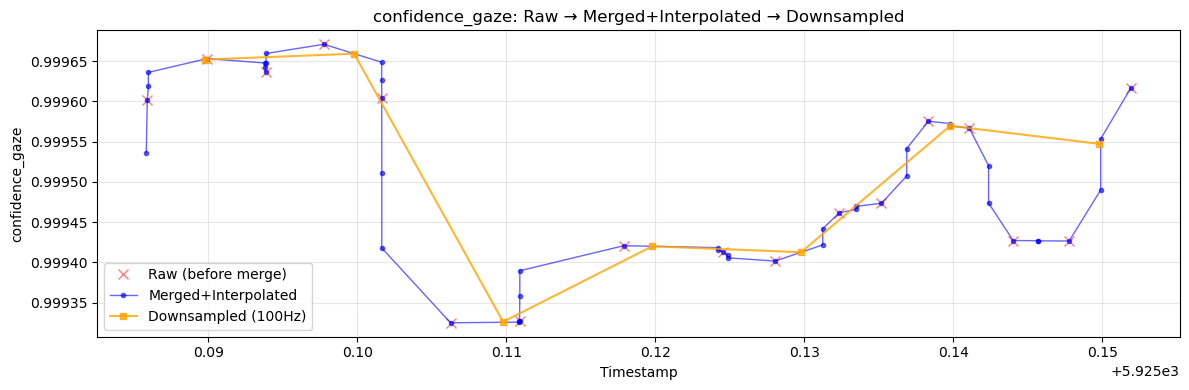

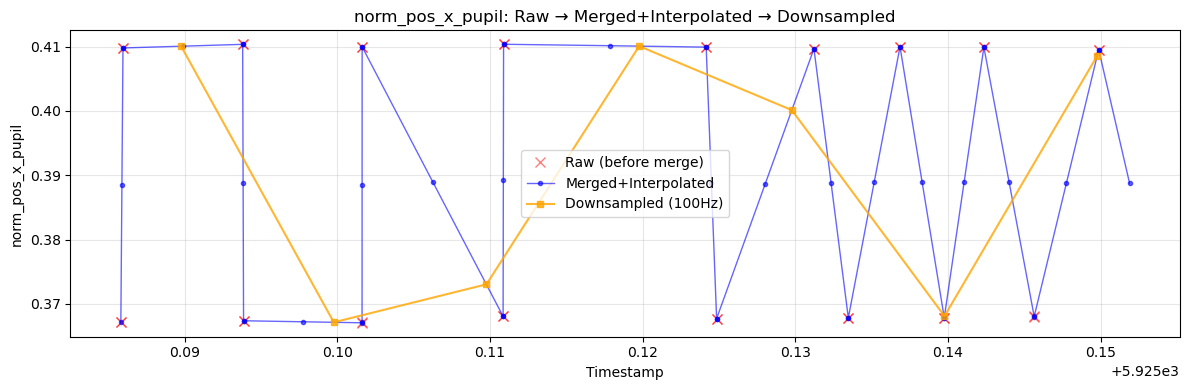

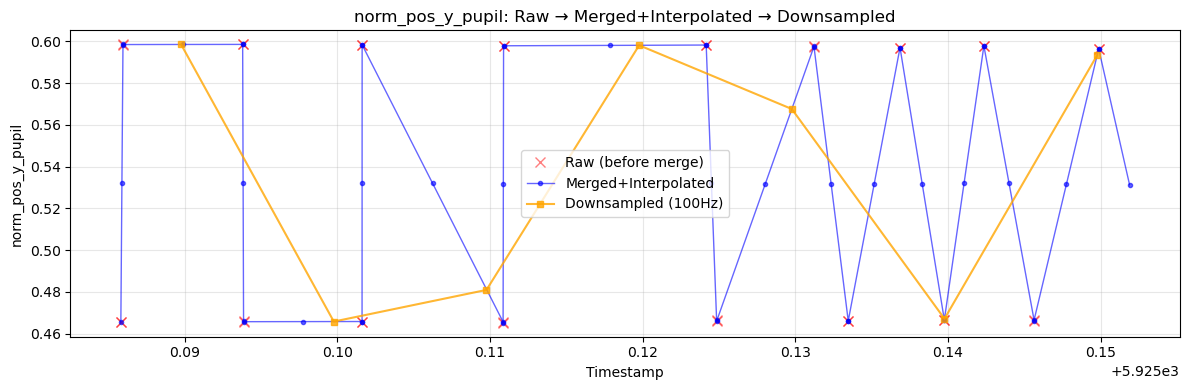

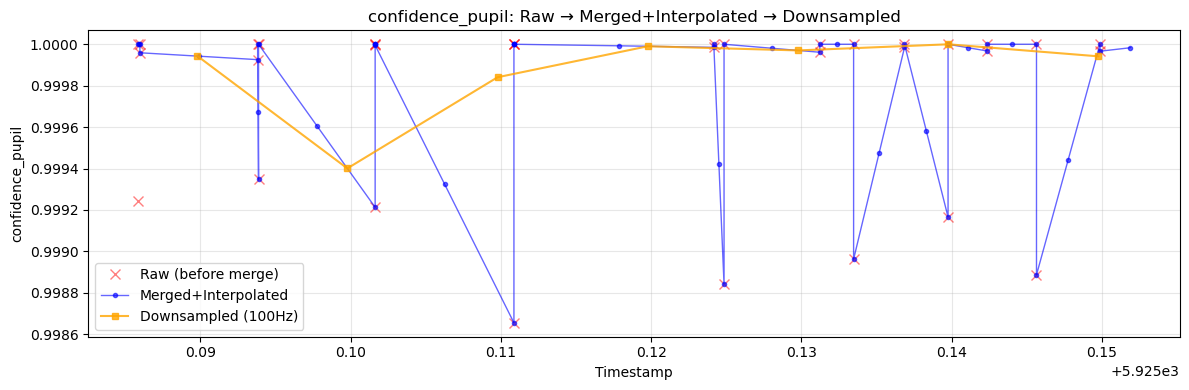


Raw gaze points in segment: 17
Raw pupil points in segment: 34
Merged+Interpolated segment: 50 samples
Downsampled segment: 7 samples
Reduction factor (raw to downsampled): 4.86x


In [14]:
# Plot comparison of original vs downsampled data
# Select a random segment of 1000 points from original data
start_idx = np.random.randint(0, len(sample_df_original) - 1000)
end_idx = start_idx + 50

segment_original = sample_df_original.iloc[start_idx:end_idx]

# Find corresponding time range in downsampled data
time_start = segment_original['timestamp'].iloc[0]
time_end = segment_original['timestamp'].iloc[-1]
segment_downsampled = sample_df_downsampled[
    (sample_df_downsampled['timestamp'] >= time_start) & 
    (sample_df_downsampled['timestamp'] <= time_end)
]

# Load raw files for the same time range to show pre-merge data
sample_dir = os.path.join(data_dir, "sample_01")
# Find which recording this segment belongs to
rec_id = segment_original['recording_id'].iloc[0]
gaze_raw = pd.read_csv(os.path.join(sample_dir, f"gaze_{rec_id}.csv"))
pupil_raw = pd.read_csv(os.path.join(sample_dir, f"pupil_{rec_id}.csv"))
gaze_raw = gaze_raw.rename(columns={'gaze_timestamp': 'timestamp'})
pupil_raw = pupil_raw.rename(columns={'pupil_timestamp': 'timestamp'})

# Filter raw data to time range
gaze_raw_segment = gaze_raw[(gaze_raw['timestamp'] >= time_start) & (gaze_raw['timestamp'] <= time_end)]
pupil_raw_segment = pupil_raw[(pupil_raw['timestamp'] >= time_start) & (pupil_raw['timestamp'] <= time_end)]

# Columns to plot
gaze_cols_plot = [
    ('norm_pos_x_gaze', 'norm_pos_x', gaze_raw_segment),
    ('norm_pos_y_gaze', 'norm_pos_y', gaze_raw_segment),
    ('confidence_gaze', 'confidence', gaze_raw_segment)
]
pupil_cols_plot = [
    ('norm_pos_x_pupil', 'norm_pos_x', pupil_raw_segment),
    ('norm_pos_y_pupil', 'norm_pos_y', pupil_raw_segment),
    ('confidence_pupil', 'confidence', pupil_raw_segment)
]

# Plot each signal
for col_merged, col_raw, raw_segment in gaze_cols_plot + pupil_cols_plot:
    fig, ax = plt.subplots(figsize=(12, 4))
    
    # Plot raw data (before merge/interpolation)
    ax.plot(raw_segment['timestamp'], raw_segment[col_raw], 
            'x', alpha=0.5, markersize=7, label='Raw (before merge)', color='red')
    
    # Plot interpolated merged data
    ax.plot(segment_original['timestamp'], segment_original[col_merged], 
            'o-', alpha=0.6, markersize=3, label='Merged+Interpolated', linewidth=1, color='blue')
    
    # Plot downsampled data
    ax.plot(segment_downsampled['timestamp'], segment_downsampled[col_merged], 
            's-', alpha=0.8, markersize=4, label='Downsampled (100Hz)', linewidth=1.5, color='orange')
    
    ax.set_xlabel('Timestamp')
    ax.set_ylabel(col_merged)
    ax.set_title(f'{col_merged}: Raw → Merged+Interpolated → Downsampled')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

print(f"\nRaw gaze points in segment: {len(gaze_raw_segment)}")
print(f"Raw pupil points in segment: {len(pupil_raw_segment)}")
print(f"Merged+Interpolated segment: {len(segment_original)} samples")
print(f"Downsampled segment: {len(segment_downsampled)} samples")
print(f"Reduction factor (raw to downsampled): {max(len(gaze_raw_segment), len(pupil_raw_segment)) / len(segment_downsampled):.2f}x")

In [10]:
# Verify annotation columns
print("Annotation columns for each recording:")
for rec_id in [1, 2, 3]:
    rec_data = sample_df_downsampled[sample_df_downsampled['recording_id'] == rec_id]
    print(f"Recording {rec_id}: Anger={rec_data['Anger'].iloc[0]}, Tenderness={rec_data['Tenderness'].iloc[0]}, "
          f"Disgust={rec_data['Disgust'].iloc[0]}, Sadness={rec_data['Sadness'].iloc[0]}")

# Check missing values in downsampled data
print("\nMissing values in downsampled data:")
gaze_sample_cols = ['norm_pos_x_gaze', 'norm_pos_y_gaze', 'gaze_point_3d_x']
pupil_sample_cols = ['norm_pos_x_pupil', 'norm_pos_y_pupil', 'diameter']
for col in gaze_sample_cols + pupil_sample_cols:
    nan_count = sample_df_downsampled[col].isna().sum()
    print(f"  {col}: {nan_count} NaN values ({100*nan_count/len(sample_df_downsampled):.2f}%)")

Annotation columns for each recording:
Recording 1: Anger=10.0, Tenderness=0.0, Disgust=10.0, Sadness=10.0
Recording 2: Anger=4.0, Tenderness=5.0, Disgust=0.0, Sadness=0.0
Recording 3: Anger=0.0, Tenderness=0.0, Disgust=0.0, Sadness=0.0

Missing values in downsampled data:
  norm_pos_x_gaze: 0 NaN values (0.00%)
  norm_pos_y_gaze: 0 NaN values (0.00%)
  gaze_point_3d_x: 0 NaN values (0.00%)
  norm_pos_x_pupil: 0 NaN values (0.00%)
  norm_pos_y_pupil: 0 NaN values (0.00%)
  diameter: 0 NaN values (0.00%)


In [ ]:
# Process all samples (1-48)
# Uncomment to run for all samples
# for sample_id in range(1, 49):
#     print(f"\n{'='*60}")
#     print(f"Processing sample {sample_id:02d}")
#     print('='*60)
#     _, _ = process_sample(sample_id, data_dir, output_dir)